In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import cftime
import nc_time_axis
import sys
import calendar
import re
sys.path.append('C:/Users/madel/Code/GeoNorth/Observational_data')

from obs_utils import *

In [2]:
# ── Target time range (CTSM-style noleap calendar) ─────────────────────────
ctsm_start = cftime.DatetimeNoLeap(1995, 1, 1, has_year_zero=True)
ctsm_end = cftime.DatetimeNoLeap(2014, 12, 31, has_year_zero=True)

# Full daily time axis — change freq="D" to e.g. "30min" if you need sub-daily
FULL_TIME = xr.date_range(
    start=ctsm_start, end=ctsm_end, freq="D", calendar="noleap", use_cftime=True
)

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\madel\Code\GeoNorth\Observational_data\IQ_obs\raw\TSOI\borehole_temperatures.csv",
    parse_dates=["date"],
)

DEPTH_COLS = [
    "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
    "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
    "900cm", "1000cm", "1200cm", "1500cm",
]

depth_m = {
    "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
    "150cm": 1.5, "200cm": 2.0, "300cm": 3.0, "400cm": 4.0,
    "500cm": 5.0, "600cm": 6.0, "700cm": 7.0, "800cm": 8.0,
    "900cm": 9.0, "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
}

# Keep only depth columns that actually exist in the file
depth_cols = [c for c in DEPTH_COLS if c in df.columns]
df = df.sort_values("date")


def df_to_tsoi_ds(station_df: pd.DataFrame) -> xr.Dataset:
    """Convert one station's wide-format dataframe into a (time, depth) Dataset."""

    # Wide -> long: one row per (date, depth)
    long_df = station_df.melt(
        id_vars=["date"],
        value_vars=depth_cols,
        var_name="depth_label",
        value_name="TSOI",
    )
    long_df["depth"] = long_df["depth_label"].map(depth_m)

    # Long -> grid: rows = time, columns = depth (meters)
    pivot = long_df.pivot_table(index="date", columns="depth", values="TSOI")
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    # Convert the pandas (Gregorian) dates to noleap cftime dates.
    # The noleap calendar has no Feb 29, so any leap-day rows can't be
    # placed on this axis — they're dropped here (rare for daily obs data;
    # flag if that's not acceptable for your use case).
    is_feb29 = (pivot.index.month == 2) & (pivot.index.day == 29)
    if is_feb29.any():
        print(f"Dropping {is_feb29.sum()} Feb-29 row(s) (no leap days in noleap calendar)")
    pivot = pivot.loc[~is_feb29]

    noleap_index = [
        cftime.DatetimeNoLeap(ts.year, ts.month, ts.day, has_year_zero=True)
        for ts in pivot.index
    ]
    pivot.index = noleap_index

    ds = xr.Dataset(
        data_vars={"TSOI": (("time", "depth"), pivot.values)},
        coords={
            "time": pivot.index,
            "depth": pivot.columns.values.astype("float64"),
        },
    )

    # Reindex onto the full 1995-01-01..2014-12-31 daily axis, filling any
    # missing dates (before/after your data, or gaps within it) with NaN.
    ds = ds.reindex(time=FULL_TIME)

    ds["TSOI"].attrs["units"] = "°C"
    ds.attrs["site"] = "IQ"
    ds.attrs["source"] = "borehole"

    return ds


# ── Build one Dataset per station_code ─────────────────────────────────────
# If your CSV only ever contains a single station, `datasets["IQAV2TC"]`
# (or whatever the code is) is the Dataset you want, matching your target.
datasets = {
    code: df_to_tsoi_ds(group)
    for code, group in df.groupby("station_code")
}

# Convenience: if there's exactly one station, expose it directly
if len(datasets) == 1:
    ds = next(iter(datasets.values()))
else:
    ds = None  # multiple stations — index into `datasets` by station_code

print(ds if ds is not None else datasets)

Dropping 1 Feb-29 row(s) (no leap days in noleap calendar)
<xarray.Dataset> Size: 993kB
Dimensions:  (time: 7300, depth: 16)
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.25 0.5 0.75 1.0 1.5 ... 9.0 10.0 12.0 15.0
Data variables:
    TSOI     (time, depth) float64 934kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     IQ
    source:   borehole


In [3]:
ds

<xarray.Dataset> Size: 993kB
Dimensions:  (time: 7300, depth: 16)
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.25 0.5 0.75 1.0 1.5 ... 9.0 10.0 12.0 15.0
Data variables:
    TSOI     (time, depth) float64 934kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     IQ
    source:   borehole

In [4]:
vari = "TSOI"

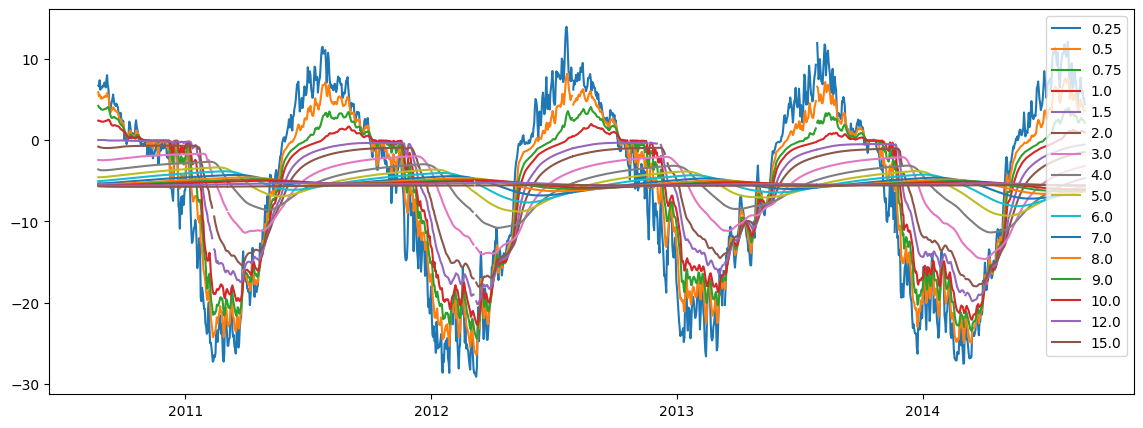

In [5]:
plot_soil_temp_depths(ds, vari)

In [6]:
ds.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/IQ_obs/processed/IQ_{vari}.nc")